In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("Commodity_Prices_cwa.csv")
df1 = df;

In [3]:
# df1.head()

In [4]:
# df1.info()

In [5]:
#dropping the last column
df1.drop(df.columns[df.columns.str.contains('unnamed', case=False)], axis=1, inplace=True)

In [6]:
# df1.head(10)

In [7]:
# seperate column for market type(F&V)
df1["Market_type"] = df1["Market"].apply(lambda x : "F&V" if "(F&V)" in x else "Grains")

In [8]:
# df1.head(10)

In [9]:
# and moving it to second
df2 = df1.iloc[:, [0, 9, 8, 1, 2, 3, 4, 5, 6, 7]]
# df2.info()

In [10]:
# df2.head()

In [11]:
# df2["Market_type"].unique() 
df2.iloc[:,0].unique()

array(['Chhindwara', 'Chaurai', 'Pandhurna', 'Chhindwara(F&V)', 'Sausar',
       'Amarwada', 'Sausar(F&V)', 'Pandhurna(F&V)'], dtype=object)

In [12]:
#fixing different codes and commodity names
len(df2.iloc[:,2].unique()) #114
len(df2.iloc[:,3].unique()) #112

112

In [13]:
ls = df.groupby("Commodity")["Commodity_Code"].unique()
# print(type(ls))
ls.iloc[: ,]
dict1 = {k : v for k, v in ls.items() if len(v) > 1}
dict1

{'Kutki': array([426, 415], dtype=int64),
 'Moath Dal': array([258,  95], dtype=int64)}

In [14]:
#extracting ids , and its comm name
double_ids = [x for i in dict1.values() for x in i]
double_ids

[426, 415, 258, 95]

In [15]:
dict2 = {i : df.loc[df["Commodity_Code"] == i, "Commodity"].values for i in double_ids}
dict2
#its safe to keep on id of each

{426: array(['Kutki', 'Kutki'], dtype=object),
 415: array(['Kutki', 'Kutki'], dtype=object),
 258: array(['Moath Dal', 'Moath Dal', 'Moath Dal', 'Moath Dal', 'Moath Dal',
        'Moath Dal', 'Moath Dal', 'Moath Dal', 'Moath Dal', 'Moath Dal',
        'Moath Dal', 'Moath Dal', 'Moath Dal', 'Moath Dal', 'Moath Dal'],
       dtype=object),
 95: array(['Moath Dal', 'Moath Dal', 'Moath Dal', 'Moath Dal', 'Moath Dal',
        'Moath Dal', 'Moath Dal', 'Moath Dal', 'Moath Dal', 'Moath Dal',
        'Moath Dal', 'Moath Dal', 'Moath Dal'], dtype=object)}

In [16]:
# df2.head()

In [17]:
#keep one ids of commodities having multiple ids
df3 = df2
df3.loc[df3["Commodity_Code"] == 426, "Commodity_Code"] = 415
df3.loc[df3["Commodity_Code"] == 258, "Commodity_Code"] = 95
# df3.loc[df3["Commodity_Code"] == 95]

In [18]:
# df3.info()

In [19]:
#check and fix Grains are not in F&Vs
df4 = df3.copy()
both_market = df3.groupby("Commodity")["Market_type"].agg(pd.Series.mode)
df4.loc[ :, "Market_type"] = df4["Commodity"].apply(lambda x : both_market[x])

In [20]:
# df4.head()

In [21]:
df5 = df4.copy()

In [22]:
#as the new F&Vs might have added fix their Market_Name
def fix_market(row):
    if row["Market_type"] == "F&V" and not (row["Market"][-5:] == ("(F&V)")):
        return row["Market"]+"(F&V)"
    elif row["Market_type"] == "Grains" and (row["Market"][-5:] == ("(F&V)")):
        return row["Market"][:-5]
    else:
        return row["Market"]
    
df5.loc[:, "Market"] = df5.apply(lambda x : fix_market(x), axis = 1)

# st = "chaurai(f&v)"
# st[-5:]

In [23]:
# df5.tail()

In [24]:
#fix zero prices
# df5

In [25]:
df6 = df5.copy()

In [26]:
# df6.head()

In [27]:
#fixing prices that are zero
# if 0 min price and max also 0, then put modal price
# if 0 min price -> adjust it accourding to modal price and max price
# if 0 max price -> adjust it accourding to modal price and min price

def fix_price(row):
    if (row["Min_Price"] + row["Max_Price"]) == 0:
        row["Min_Price"] = row["Modal_Price"]
        row["Max_Price"] = row["Modal_Price"]
    elif row["Min_Price"] == 0:
        row["Min_Price"] = row["Modal_Price"]*2 - row["Max_Price"]
    elif row["Max_Price"] == 0:
        row["Max_Price"] = row["Modal_Price"]*2 - row["Min_Price"]
    return row
        
df6 = df6.apply(lambda x : fix_price(x), axis = 1)
# df6[df6["Max_Price"] == 0]

In [28]:
# df6.tail()

In [29]:
#make separate column for available since date
df7 = df6.copy()
df7['Arrival_Date'] = pd.to_datetime(df7['Arrival_Date'], format='%d-%m-%Y')

In [30]:
df7["First_Date"] = df7.groupby("Commodity")["Arrival_Date"].transform("min")
# df7.head()

In [31]:
#column for the years of data present for each commodity
# df7.tail()

In [32]:
df7["Years_Age"]=df7.loc[:, "Arrival_Date"].dt.year - df7.loc[:, "First_Date"].dt.year
# df7.head()

In [33]:
df8 = df7.iloc[:, [0, 1, 2, 3, 4, 5, 6, 10, 11, 7, 8, 9]]

In [34]:
# df8

In [35]:
#we have finished data cleaning
#now moving on to data transformation

# making df of top commodities
# cwa region, cwa f&v
# market_type seperate, 
# top costliest,  
# last 4 or n years stuff
# top 5 or top 10
# price of top crops over the years

In [36]:
# df8.head()

In [37]:
# cwa region, analysis
#contains all cwa
df_cwa = df8.loc[df8["Market"].isin(["Chhindwara","Chhindwara(F&V)"]), :]

#contains only grains in cwa
df_cwa_g = df_cwa.loc[df_cwa["Market_type"] == "Grains",:]

#contains only f&v in cwa
df_cwa_fnv = df_cwa.loc[df_cwa["Market_type"] == "F&V", :]

# **Top N**

In [38]:
#top commodities in cwa region by years active
cwa_oldest = df_cwa.groupby("Commodity")["Years_Age"].max().sort_values(ascending = False)

In [39]:
#top commodities in cwa region with most varieties
cwa_diverse = df_cwa.groupby("Commodity")["Variety"].unique().apply(lambda x : len(x)).sort_values(ascending = False)

In [40]:
#top costliest commodities in cwa region
cwa_expensive = df_cwa.groupby("Commodity")["Modal_Price"].max().sort_values(ascending = False)

**Last N Years**

In [41]:
#last 10 years analysis
df_cwa_old = df_cwa.loc[df_cwa["First_Date"].dt.year < 2014, :]
df_cwa_new = df_cwa.loc[df_cwa["First_Date"].dt.year > 2014, :]

df_cwa_fv_old = df_cwa_old.loc[df_cwa_old["Market_type"] == "F&V", :]
df_cwa_fv_new = df_cwa_new.loc[df_cwa_new["Market_type"] == "F&V", :]

#### **Prices of top grain commodities in CWA region over the years**

In [42]:
#top commodities in cwa region by years active in grains
cwa_top_grains=df_cwa_g.groupby("Commodity")["Years_Age"].max().sort_values(ascending = False)[:8].sort_index()
cwa_top_grains

Commodity
Arhar (Tur/Red Gram)(Whole)    22
Jowar(Sorghum)                 22
Lentil (Masur)(Whole)          22
Maize                          22
Mustard                        22
Rajgir                         22
Soyabean                       22
Wheat                          22
Name: Years_Age, dtype: int32

In [43]:
def rate_over_years(comm, clr, dff):
    comm_cwa =dff.loc[dff["Commodity"] == comm, :]
    return comm_cwa.groupby(comm_cwa["Arrival_Date"].dt.year)["Modal_Price"].mean().round().plot(kind = "line", color = clr, lw = 1.5)

Wheat

In [44]:
# rate_over_years("Wheat", "green", df_cwa)

In [45]:
# rate_over_years("Maize", "orange", df_cwa)

Mustard

In [46]:
# rate_over_years("Mustard", "yellow", df_cwa)

In [47]:
# rate_over_years("Soyabean", "red", df_cwa)

Arhar (Tur/Red Gram)(Whole)

In [48]:
# rate_over_years("Arhar (Tur/Red Gram)(Whole)", "yellow", df_cwa)

#### **Prices of top F&V commodities in CWA region over the years**

In [49]:
#top commodities in cwa region by years active in fnv
cwa_top_fnv=df_cwa_fnv.groupby("Commodity")["Years_Age"].max().sort_values(ascending = False)[:10]
cwa_top_fnv

Commodity
Onion                22
Tomato               22
Green Chilli         22
Potato               21
Green Peas           21
Coriander(Leaves)    21
Garlic               21
Carrot               17
Methi(Leaves)        17
Capsicum             16
Name: Years_Age, dtype: int32

In [50]:
def plotting(X, Y):
    plt.plot(X, Y)
    return plt.show()

#### **Simple Moving Average (SMA)**

In [51]:
def sma(comm , x):
    data = df_cwa.loc[(df_cwa["Commodity"] == comm) & (df_cwa["Arrival_Date"].dt.year == 2024), ["Arrival_Date","Modal_Price"]].set_index("Arrival_Date").sort_index()
    data["rolling_avg"] = data["Modal_Price"].rolling(x).mean()
    return data.plot(figsize=(9, 5), lw = 2)

# sma("Wheat", 30)
# sma("Maize", 30)

#### **Weighted Moving Average (WMA)**

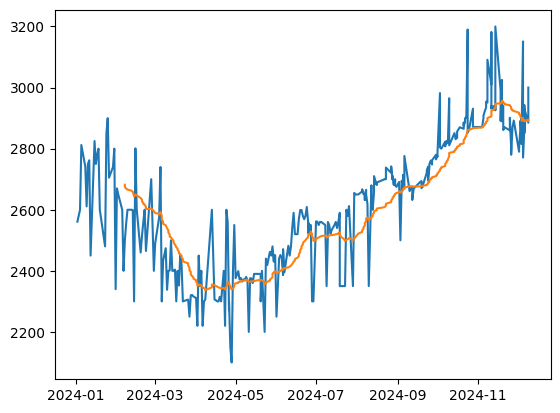

In [52]:
def wma(comm, n):
    data = df_cwa.loc[(df_cwa["Commodity"] == comm) & (df_cwa["Arrival_Date"].dt.year == 2024), ["Arrival_Date","Modal_Price"]].sort_values(by=["Arrival_Date"], ascending = False).reset_index(drop=True)
    for i in range(0, data.shape[0] - n):
        j = n
        res = 0
        for j in range(j , 0, -1):
            res += data.iloc[n - j + i, 1]* j 
        res /= (n*(n+1))/2
        data.loc[i, "WMA_"+str(n)] = res.round(2)
    # plt.plot(data.iloc[:, [1,2]])
    # plt.show
    plotting(data.iloc[:,0], data.iloc[:,[1,2]])
    return None
    
wma("Wheat", 50)

#### **Exponential Moving Average (EMA)**

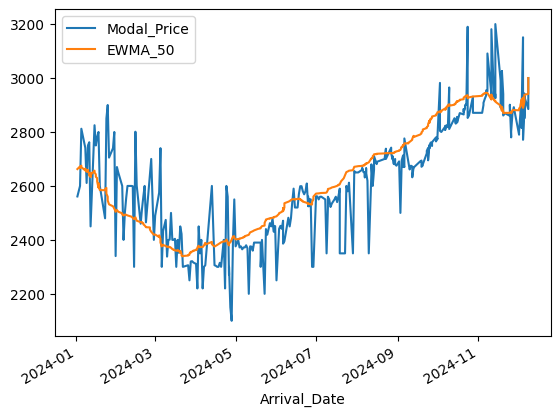

In [53]:
def ema_plot(comm, span):
    data = df_cwa.loc[(df_cwa["Commodity"] == "Wheat") & (df_cwa["Arrival_Date"].dt.year == 2024), ["Arrival_Date","Modal_Price"]].sort_values(by=["Arrival_Date"], ascending = False).reset_index(drop=True)
    data["EWMA_50"] = data.iloc[:,1].ewm(span = span).mean()
    data.set_index("Arrival_Date", inplace = True)
    data.plot()

ema_plot("Wheat", 50)

#### **Volatility Indicators**

In [54]:
def bollinger_bands_plot(win_size, n_std, comm):
    data = df_cwa.loc[(df_cwa["Commodity"] == comm) & (df_cwa["Arrival_Date"].dt.year == 2024), ["Arrival_Date","Modal_Price"]].sort_values(by=["Arrival_Date"], ascending = False).reset_index(drop=True)
    data = data.set_index("Arrival_Date")
    
    window_size = win_size  # Adjust window size as needed
    num_std = n_std      # Adjust number of standard deviations as needed

    rolling_mean = data['Modal_Price'].rolling(window_size).mean()
    rolling_std = data['Modal_Price'].rolling(window_size).std()
    
    data['UpperBand_3'] = rolling_mean + (num_std * rolling_std)
    data['LowerBand_3'] = rolling_mean - (num_std * rolling_std)
    
    #signals for overbought/oversold
    data["Overbought"] = data["Modal_Price"] > data["UpperBand_3"]
    data["Oversold"] = data["Modal_Price"] < data["LowerBand_3"]

    # Plotting
    plt.figure(figsize=(12, 6))
    plt.plot( data['Modal_Price'], label='Close Modal_Price', lw=0.5, color = "black")
    plt.plot( rolling_mean, label='Moving Average')
    plt.plot( data['UpperBand_3'], label='Upper Band')
    plt.plot( data['LowerBand_3'], label='Lower Band')
    plt.fill_between(data.index, data['UpperBand_3'], data['LowerBand_3'], alpha=0.2)
    
    # Highlight overbought and oversold points
    plt.scatter(data.index[data['Overbought']], data['Modal_Price'][data['Overbought']], color='red', label='Overbought', marker='o')
    plt.scatter(data.index[data['Oversold']], data['Modal_Price'][data['Oversold']], color='green', label='Oversold', marker='o')
    
    plt.legend()
    plt.title('Bollinger Bands')
    plt.xlabel('Time')
    plt.ylabel('Modal_Price')
    plt.show()


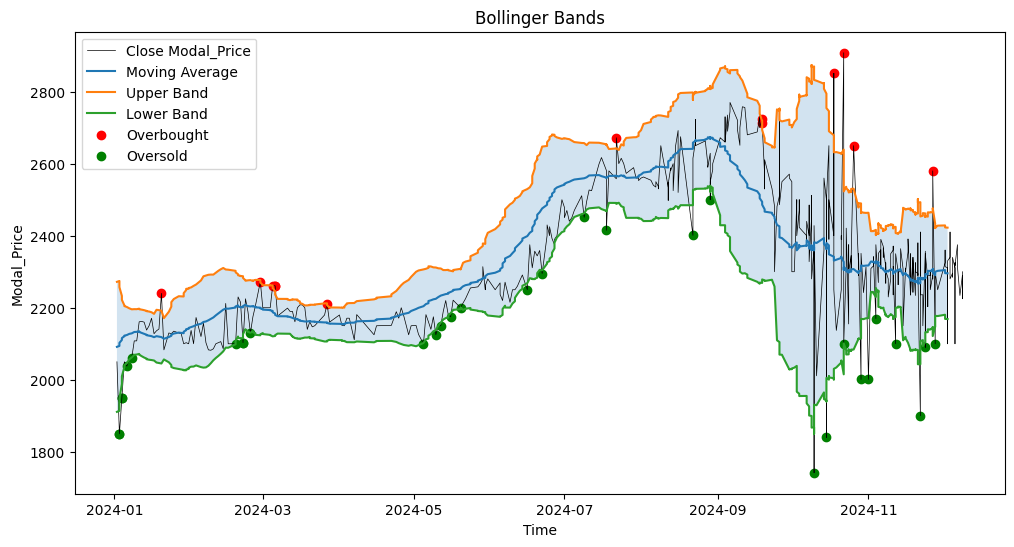

In [55]:
bollinger_bands_plot(30, 2, "Maize")

#### **Creating lagged features**

In [57]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [58]:
def predict_tts(comm):
    data = df_cwa.loc[(df["Commodity"] == comm) , ["Arrival_Date", "Modal_Price"]].sort_values(by = ["Arrival_Date"]).reset_index(drop= True)
    data.set_index("Arrival_Date", inplace = True)

    data = pd.DataFrame(data)
    #creating lagged features
    data["Lag_1"] = data["Modal_Price"].shift(1)
    data["Lag_2"] = data["Modal_Price"].shift(2)
    data["Target"] = data["Modal_Price"].shift(-1)
    data.dropna(inplace = True)

    # Split into features (X) and target (y)
    X = data.loc[:, ["Lag_1", "Lag_2"]]
    y = data.loc[:, ["Target"]]

    #Split your data into training and test sets
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    # Initialize the model
    model = LinearRegression()
    
    # Train the model
    model.fit(X_train, y_train)
    
    # Predict on the test set
    y_pred = model.predict(X_test)
    
    # Evaluate predictions
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)

    print("Test Data")
    print(f"Mean Absolute Error(Test): {mae}")
    print(f"Mean Squared Error(Test): {mse} \n")

    # # Predict on the test set
    # y_pred1 = model.predict(X_train)

    # # Evaluate predictions
    # mae1 = mean_absolute_error(y_train, y_pred1)
    # mse1 = mean_squared_error(y_train, y_pred1)

    # print("Training Data")
    # print(f"Mean Absolute Error: {mae1}")
    # print(f"Mean Squared Error: {mse1}")

    
    # # Plot actual vs predicted
    # plt.figure(figsize=(10, 6))
    # plt.plot(y_test.values, label='Actual Prices', marker='o', lw = 1)
    # plt.plot(y_pred, label='Predicted Prices', marker='.')
    # plt.legend()
    # plt.title('Actual vs Predicted Prices')
    # plt.xlabel('Index')
    # plt.ylabel('Price')
    # plt.show()

    # Scatter plot
    plt.figure(figsize=(8, 6))
    plt.scatter(y_test.values, y_pred, color='blue', label='Predictions', s = 3)
    plt.plot([min(y_test.values), max(y_test.values)], [min(y_test.values), max(y_test.values)], 
             color='red', linestyle='--', label='Perfect Prediction Line')
    
    # Add labels and legend
    plt.title('Actual vs Predicted Prices')
    plt.xlabel('Actual Prices')
    plt.ylabel('Predicted Prices')
    plt.legend()
    plt.grid(True)
    plt.show()

    #forecasting
    vector = {"Lag_1":[data.iloc[-1, 0]],"Lag_2":[data.iloc[-2, 0]]}
    df_fc = pd.DataFrame(vector) 
    print("Next Price : ",model.predict(df_fc)[0])


    #rolling predictions forward (1 year)
    preds = []
    for _ in range(365):
        x = model.predict(df_fc)[0][0]
        df_fc.iloc[0,1] = df_fc.iloc[0,0]
        df_fc.iloc[0,0] = x
        preds.append(x)

    # print("Predictions of next 365 days", preds)
    plt.plot(preds) 
    plt.xlabel('Index')
    plt.ylabel('Value')
    plt.title('For 2025')
    plt.show()
    # Example historical prices
    historical_prices = data['Modal_Price'].tolist() # Replace with actual data
    forecasted_prices = preds  # From the multi-step prediction
    
    # Combine historical and forecasted data
    all_prices = historical_prices + forecasted_prices
    time_steps = list(range(len(all_prices)))
    
    # Plot
    plt.plot(time_steps[:len(historical_prices)], historical_prices, label="Historical Prices", marker=".", lw = 0.1)
    plt.plot(time_steps[len(historical_prices):], forecasted_prices, label="Forecasted Prices", marker=".", lw = 0.1)
    plt.xlabel("Time Steps")
    plt.ylabel("Price")
    plt.legend()
    plt.title("Historical vs. Forecasted Prices")
    plt.show()

    # feature importance
    feature_names = ['Lag_1', 'Lag_2']
    coefficients = model.coef_.ravel()

    feature_importance = pd.DataFrame({
        'Feature': feature_names,
        'Importance': coefficients
    }).sort_values(by='Importance', ascending=False)
    
    print(feature_importance)
        

Test Data
Mean Absolute Error(Test): 36.09032835126427
Mean Squared Error(Test): 3316.6309374714406 



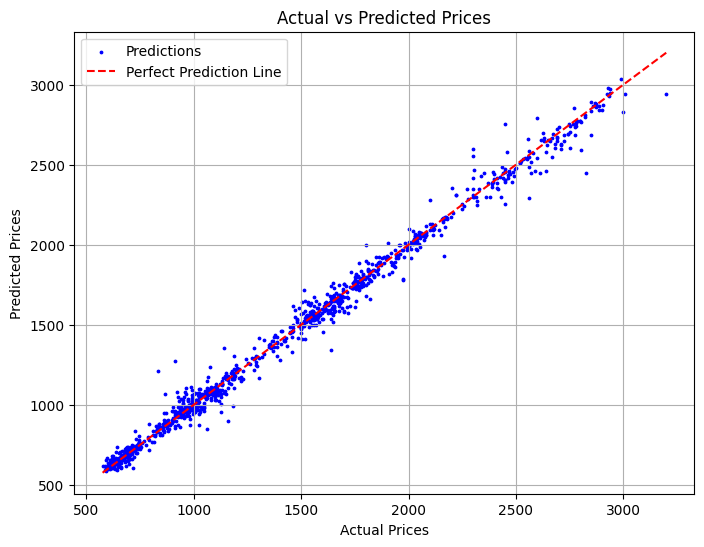

Next Price :  [2875.03363407]


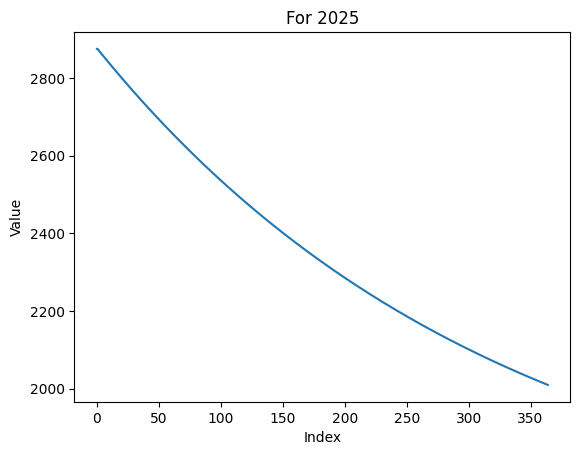

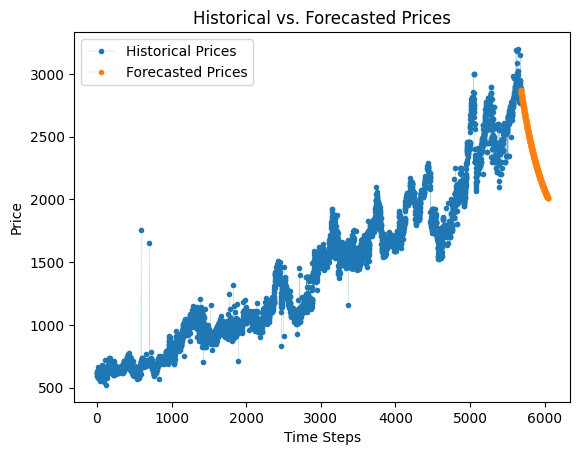

  Feature  Importance
0   Lag_1    0.567133
1   Lag_2    0.428493


In [59]:
predict_tts("Wheat")

## **Seasonality Analysis**

In [61]:
from statsmodels.tsa.stattools import adfuller

In [62]:
def adf_test(series, signif=0.05):
    #Perform ADF test on the series
    result = adfuller(series) 
    
    #Output of the test
    output = {'Test Statistic':result[0], 'p-value':result[1], 'No. of Lags':result[2], 
              'No. of Observations':result[3], 'Critical Values':result[4]}
    
    #Print summary
    print('Augmented Dickey-Fuller Test:')
    for key, value in output.items():
        print(f'{key}: {value}')
    
    #Interpretation
    if result[1] <= signif:
        print(f"Strong evidence against the null hypothesis, reject the null hypothesis. Data has no unit root and is likely stationary.")
    else:
        print(f"Weak evidence against null hypothesis, time series has a unit root, indicating it is non-stationary.")
    print('\n')

In [63]:
for x in df_cwa["Commodity"].unique():
    if len(df_cwa.loc[df_cwa["Commodity"] == x]) < 50:
        continue
    print(x)
    data1 = df_cwa.loc[(df_cwa["Commodity"] == x), ["Arrival_Date", "Modal_Price"]].sort_values(by="Arrival_Date").reset_index(drop=True)
    data1.set_index("Arrival_Date", inplace = True)
    adf_test(data1['Modal_Price'])
     

Green Gram Dal (Moong Dal)
Augmented Dickey-Fuller Test:
Test Statistic: -0.6145131855115514
p-value: 0.8676688040724786
No. of Lags: 2
No. of Observations: 202
Critical Values: {'1%': -3.4631437906252636, '5%': -2.8759570379821047, '10%': -2.574454682874228}
Weak evidence against null hypothesis, time series has a unit root, indicating it is non-stationary.


Maize
Augmented Dickey-Fuller Test:
Test Statistic: -1.1022287196616425
p-value: 0.7141822995962213
No. of Lags: 33
No. of Observations: 5736
Critical Values: {'1%': -3.431490555935115, '5%': -2.862044016625176, '10%': -2.567038286212358}
Weak evidence against null hypothesis, time series has a unit root, indicating it is non-stationary.


Garlic
Augmented Dickey-Fuller Test:
Test Statistic: -0.8870691377328533
p-value: 0.7922009049867365
No. of Lags: 12
No. of Observations: 1018
Critical Values: {'1%': -3.4367899468008916, '5%': -2.8643833180472744, '10%': -2.5682839089705536}
Weak evidence against null hypothesis, time series h

In [64]:
from statsmodels.tsa.seasonal import seasonal_decompose

In [65]:
def season(data):
    ls = [90, 150, 180, 270, 360, 720]
    # Decompose the time series
    for n in ls:
        decomposition = seasonal_decompose(data['Modal_Price'], model='multiplicative', period = (n))
        
        seasonal = decomposition.seasonal
        # Plot decomposition
        plt.figure(figsize=(12, 8))
        plt.subplot(4, 1, 3)
        plt.plot(seasonal, label='Seasonality '+str(n), color='green')
        plt.legend(loc='upper left')
        plt.tight_layout()
        plt.show()    

In [66]:
def decompose(comm):
    # & (df_cwa["Arrival_Date"].dt.year < 2019)
    data = df_cwa.loc[(df_cwa["Commodity"] == comm), ["Arrival_Date", "Modal_Price"]].sort_values(by="Arrival_Date").reset_index(drop=True)
    data.set_index("Arrival_Date", inplace = True)
    # print(data)
    data['Modal_Price'].plot(figsize=(10, 6), title='Original Time Series', ylabel='Price')
    plt.show()
    
    # season(data)
    # Decompose the time series
    decomposition = seasonal_decompose(data['Modal_Price'], model='additive', period = (120))
    
    # Extract components
    trend = decomposition.trend
    seasonal = decomposition.seasonal
    residual = decomposition.resid

    # Plot decomposition
    plt.figure(figsize=(12, 8))
    
    plt.subplot(4, 1, 1)
    plt.plot(data['Modal_Price'], label='Original')
    plt.legend(loc='upper left')
    
    plt.subplot(4, 1, 2)
    plt.plot(trend, label='Trend', color='orange')
    plt.legend(loc='upper left')
    
    plt.subplot(4, 1, 3)
    plt.plot(seasonal, label='Seasonality', color='green')
    plt.legend(loc='upper left')
    
    plt.subplot(4, 1, 4)
    plt.plot(residual, label='Residuals', color='red')
    plt.legend(loc='upper left')
    
    plt.tight_layout()
    plt.show()

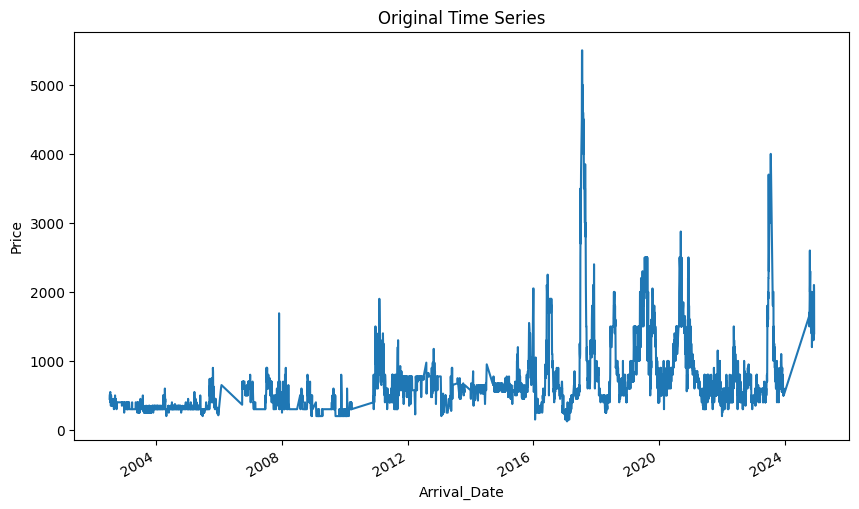

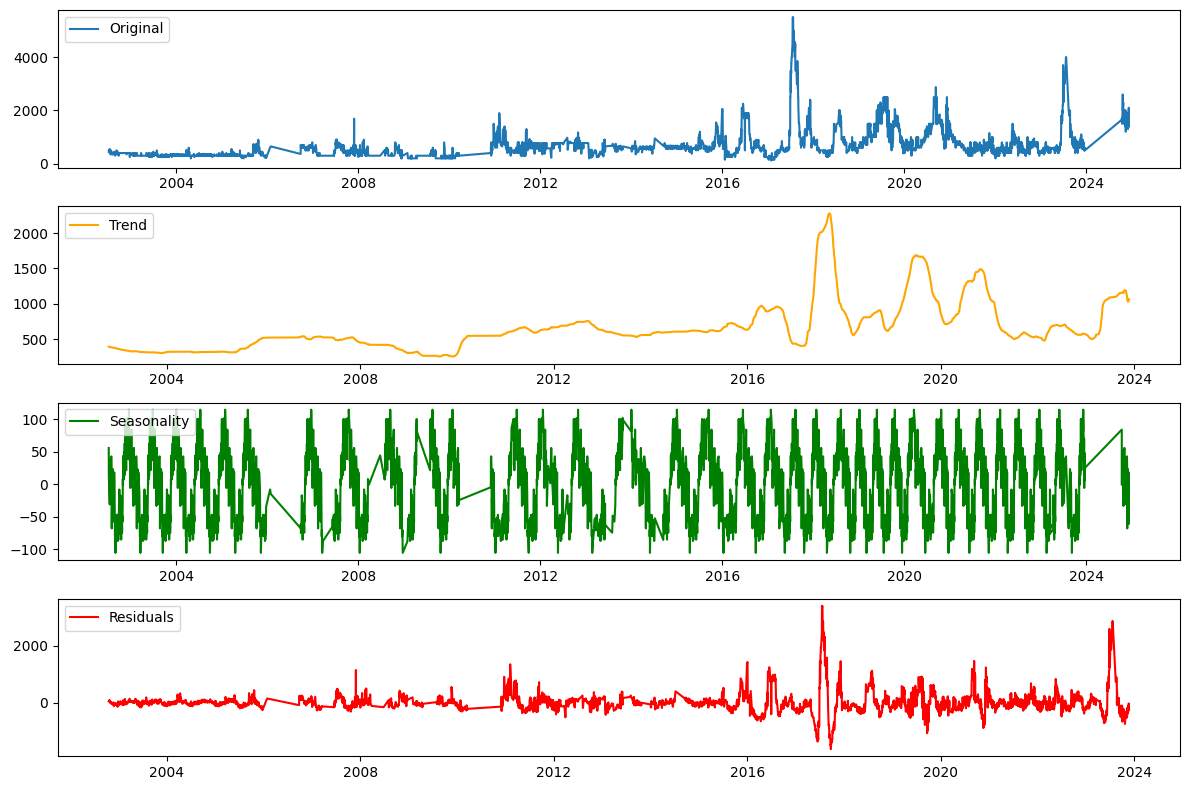

In [67]:
decompose("Tomato")

##  Scenario Analysis

    Objective: Test how the model responds to hypothetical scenarios. Like MSP is fixed to 2400 from 2200